In [4]:
import matplotlib.pyplot as plt

import PIL

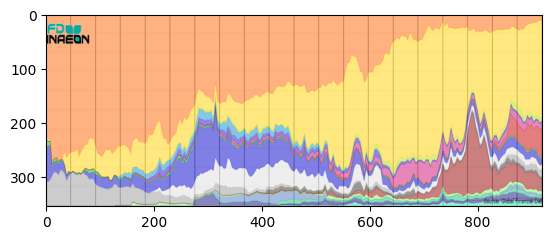

In [73]:
file = "data/market_cap_graph.png"

img = PIL.Image.open(file)

# crop the image to just the graph area (adjust these values based on your image)
cropped_img = img.crop((45, 21, 965, 376))  # (left, upper, right, lower)
# cropped_img = img.crop((900, 300, 966, 376))  # (left, upper, right, lower)

i = plt.imshow(cropped_img)

In [72]:
cropped_img.show()

In [98]:
data_range = (1782, 2022)

x_pixels = cropped_img.width

# Map pixel x-coordinates to years
def pixel_to_year(x):
    return (data_range[0] + (x / (x_pixels - 1)) * (data_range[1] - data_range[0]))

pixel_years = {x: round(pixel_to_year(x)) for x in range(x_pixels)}

country_colors = {
    "US": "#fee881",
    "UK": "#fdb462",
    "DE": "#eeeeee",
    "FR": "#807fe5",
    "JP": "#cb7f7f",
}

# Now you can use pixel_years to find the corresponding year for any x-coordinate in the cropped image

# construct a bitmap of hex colors for each pixel in the cropped image
pixels = list(cropped_img.getdata()) 
# filter alpha
pixels = [pixel[:3] for pixel in pixels]
pixels = ['#%02x%02x%02x' % p for p in pixels]
width, height = img.size
hex_array_2d = [pixels[i:i + width] for i in range(0, len(pixels), width)]

C:\Users\CallumDavidson\AppData\Local\Temp\ipykernel_33104\3465782606.py:22: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  pixels = list(cropped_img.getdata())


In [ ]:
def get_percentages_for_year(year, hex_array_2d, pixel_years, country_colors):
    # Find the x-coordinate for the given year
    x = None
    x_coordinates = []
    for x_coord, yr in pixel_years.items():
        if yr == year:
            x_coordinates.append(x_coord)
    if not x_coordinates:
        return None  # Year not found in pixel mapping
    out = {}

    # transpose the hex_array_2d to get columns as lists
    hex_array_2d = list(map(list, zip(*hex_array_2d)))
    
    for x in x_coordinates:
        column = hex_array_2d[x]
        for country, color in country_colors.items():
            count = column.count(color)
            out[country] = out.get(country, 0) + count

get_percentages_for_year(1900, hex_array_2d, pixel_years, country_colors)

IndexError: list index out of range

In [109]:
x_coordinates = []
for x_coord, yr in pixel_years.items():
    if yr == 1900:
        x_coordinates.append(x_coord)

In [110]:
x_coordinates

[450, 451, 452, 453]

In [111]:
len(hex_array_2d)

335